# t-SNE

## Overview

t-SNE (t-distributed Stochastic Neighbour Embedding) is a non-linear dimensionality reduction method designed for visualisation of high-dimensional data in 2D or 3D. It preserves local neighbourhood structure, making cluster separation clearly visible.

**Critical properties to understand:**
- t-SNE is for **visualisation only** — the 2D coordinates have no interpretable axis meaning
- **Distances between clusters are not meaningful** — only neighbourhood membership matters
- Results are **stochastic** — different runs produce different layouts
- The `perplexity` parameter controls the effective number of neighbours (typically 5–50)
- **Always run PCA first** to reduce to ~50 dimensions before t-SNE on high-dimensional data

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
# Four ecological site clusters with non-linear relationships
centers = [(50,7.8,1.2,0.8),(200,7.1,3.5,2.0),(350,6.5,6.0,3.5),(150,7.4,2.0,1.2)]
X_list, labels = [], []
for i, (elev,ph,nit,phos) in enumerate(centers):
    n = rng.integers(60,80)
    X_list.append(np.column_stack([
        rng.normal(elev,40,n), rng.normal(ph,0.25,n),
        rng.gamma(2,nit/2,n), rng.gamma(2,phos/2,n)
    ]))
    labels.extend([i]*n)
X = np.vstack(X_list)
labels = np.array(labels)
feat_names = ["elevation","ph","nitrate","phosphorus"]
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f"Dataset: {X.shape}, clusters: {len(set(labels))}")

Dataset: (276, 4), clusters: 4


---
## Fitting t-SNE

KL divergence: 0.4282  (lower = better fit)


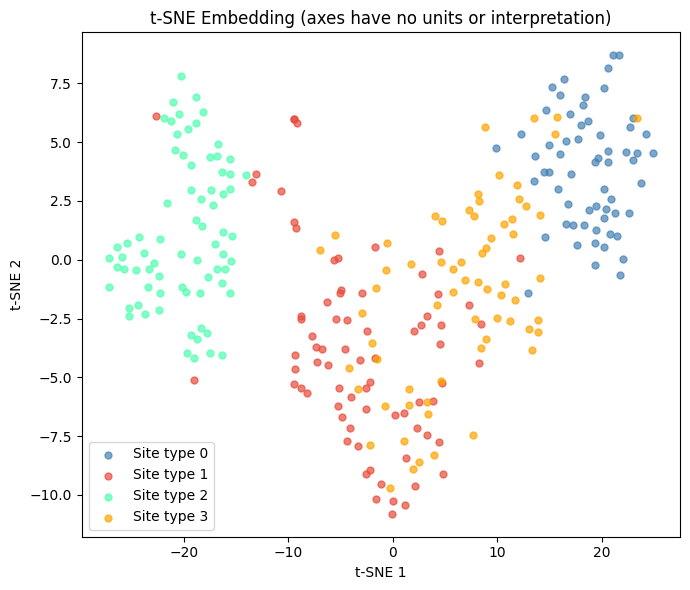

In [3]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sc)
print(f"KL divergence: {tsne.kl_divergence_:.4f}  (lower = better fit)")
fig, ax = plt.subplots(figsize=(7,6))
colors = ["steelblue","#e74c3c","#4fffb0","orange"]
for k in range(4):
    mask = labels == k
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], s=25, alpha=0.7,
               color=colors[k], label=f"Site type {k}")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE Embedding (axes have no units or interpretation)")
ax.legend(); plt.tight_layout(); plt.show()

---
## Perplexity Sensitivity

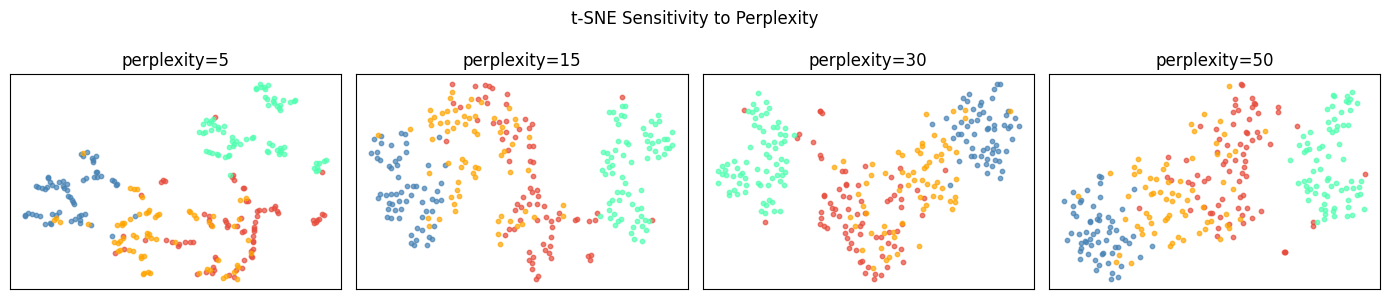

Perplexity ~= effective number of neighbours
Too low: fragmented; Too high: global structure dominates, clusters merge


In [4]:
fig, axes = plt.subplots(1,4,figsize=(14,3))
for ax, perp in zip(axes, [5, 15, 30, 50]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca",
               learning_rate="auto", random_state=42).fit_transform(X_sc)
    for k in range(4):
        mask = labels == k
        ax.scatter(emb[mask,0], emb[mask,1], s=10, alpha=0.7, color=colors[k])
    ax.set_title(f"perplexity={perp}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("t-SNE Sensitivity to Perplexity")
plt.tight_layout(); plt.show()
print("Perplexity ~= effective number of neighbours")
print("Too low: fragmented; Too high: global structure dominates, clusters merge")

---
## PCA then t-SNE (Recommended for High-d Data)

Variance retained by pre-PCA: 1.000


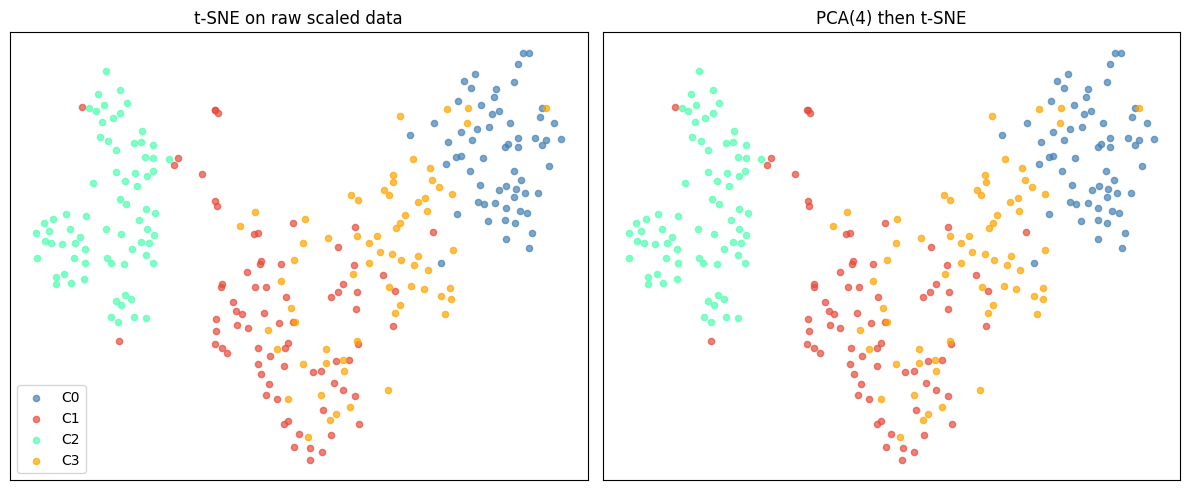

In [5]:
# PCA to 10 components first, then t-SNE
# For truly high-d data (e.g. gene expression, species matrices) this is essential
pca_pre = PCA(n_components=4, random_state=42)
X_pca = pca_pre.fit_transform(X_sc)
print(f"Variance retained by pre-PCA: {pca_pre.explained_variance_ratio_.sum():.3f}")
tsne_pca = TSNE(n_components=2, perplexity=30, init="pca",
                learning_rate="auto", random_state=42)
X_tsne_pca = tsne_pca.fit_transform(X_pca)
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, emb, title in zip(axes,
    [X_tsne, X_tsne_pca],
    ["t-SNE on raw scaled data","PCA(4) then t-SNE"]):
    for k in range(4):
        mask = labels == k
        ax.scatter(emb[mask,0], emb[mask,1], s=20, alpha=0.7, color=colors[k], label=f"C{k}")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend()
plt.tight_layout(); plt.show()

---
## Colouring by Continuous Features

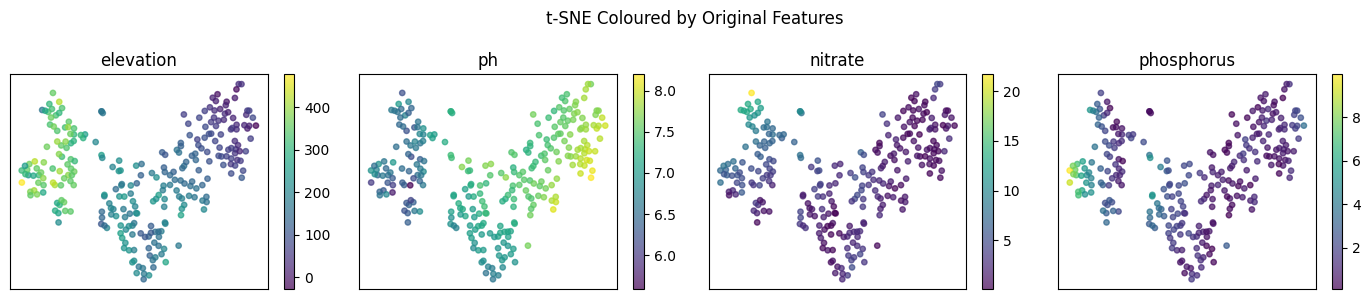

Colouring by features reveals which variables drive cluster separation
Do not infer that nearby points are similar on ALL features -- only locally


In [6]:
fig, axes = plt.subplots(1,4,figsize=(14,3))
for ax, feat, vals in zip(axes, feat_names, X.T):
    sc = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=vals, s=15, alpha=0.7, cmap="viridis")
    plt.colorbar(sc, ax=ax)
    ax.set_title(feat); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("t-SNE Coloured by Original Features")
plt.tight_layout(); plt.show()
print("Colouring by features reveals which variables drive cluster separation")
print("Do not infer that nearby points are similar on ALL features -- only locally")

---

## Common Pitfalls

**1. Interpreting distances between t-SNE clusters**  
t-SNE preserves local neighbourhood structure but distorts global distances. Two clusters that appear far apart may be similar in original feature space; two clusters close together may not be genuinely similar. Never interpret inter-cluster distances in a t-SNE plot.

**2. Not running t-SNE multiple times to check stability**  
t-SNE is stochastic. Run with at least 3 different `random_state` values and check that the cluster structure is consistent. If the layout changes substantially between runs, the structure is not robust.

**3. Using t-SNE for anything other than visualisation**  
t-SNE coordinates cannot be used as features in downstream models, cannot be applied to new data with `transform()`, and have no interpretable axes. For downstream use, apply PCA or UMAP instead.

**4. Using default `init="random"` for large datasets**  
`init="pca"` initialises from PCA coordinates, which gives more deterministic and often better results. It is the recommended default since sklearn 1.2 and should be set explicitly for reproducibility.

**5. Running t-SNE on raw high-dimensional data without pre-reducing**  
For data with more than ~50 features, run PCA first to reduce to 20–50 dimensions. This removes noise, speeds up t-SNE substantially, and often produces cleaner embeddings.


---
*python_methods_library - Samantha McGarrigle*